# Football Match Prediction - Exploratory Data Analysis & Feature Engineering

This notebook covers the full pipeline from raw data loading to model training for predicting international football match outcomes.

## Table of Contents
1. [Setup & Configuration](#setup)
2. [Data Loading & Cleaning](#loading)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Feature Engineering](#features)
5. [Model Training & Evaluation](#models)
6. [Group Standings Computation](#standings)

---
## 1. Setup & Configuration <a id='setup'></a>

We start by importing the required libraries and defining two key mapping dictionaries:

- **`ELO_ABBR_MAP`**: Maps Elo rating abbreviation codes (e.g. `"ES"` → `"Spain"`) to standardised country names.
- **`DATASET_NAME_MAP`**: Harmonises different spelling variants that appear across datasets (e.g. `"Korea Republic"` → `"South Korea"`, `"Türkiye"` → `"Turkey"`).

These mappings are critical because data comes from multiple sources (match results CSV, FIFA rankings, Elo ratings) and each uses slightly different naming conventions.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV

In [2]:
ELO_ABBR_MAP = {
    "ES": "Spain", "AR": "Argentina", "FR": "France", "EN": "England",
    "CO": "Colombia", "BR": "Brazil", "PT": "Portugal", "NL": "Netherlands",
    "EC": "Ecuador", "HR": "Croatia", "NO": "Norway", "DE": "Germany",
    "CH": "Switzerland", "UY": "Uruguay", "TR": "Turkey", "JP": "Japan",
    "DK": "Denmark", "IT": "Italy", "BE": "Belgium", "MA": "Morocco",
    "MX": "Mexico", "PY": "Paraguay", "AT": "Austria", "SN": "Senegal",
    "UA": "Ukraine", "CA": "Canada", "SQ": "Serbia",
    "KR": "South Korea", "RU": "Russia", "AU": "Australia",
    "RS": "Serbia", "GR": "Greece", "DZ": "Algeria", "IR": "Iran", "US": "USA",
    "PA": "Panama", "PL": "Poland", "UZ": "Uzbekistan",
    "CZ": "Czech Republic", "CL": "Chile", "WA": "Wales",
    "VE": "Venezuela", "KO": "Kosovo", "PE": "Peru", "HU": "Hungary",
    "SI": "Slovenia", "JO": "Jordan", "IE": "Republic of Ireland",
    "SK": "Slovakia", "NG": "Nigeria", "BO": "Bolivia", "AL": "Albania",
    "SE": "Sweden", "CD": "DR Congo", "GE": "Georgia", "RO": "Romania",
    "CR": "Costa Rica", "IL": "Israel", "CI": "Ivory Coast", "EG": "Egypt",
    "TN": "Tunisia", "EI": "North Macedonia", "ML": "Mali",
    "CM": "Cameroon", "NM": "Montenegro",
    "SA": "Saudi Arabia", "NZ": "New Zealand", "IQ": "Iraq",
    "BA": "Bosnia and Herzegovina", "BF": "Burkina Faso", "HN": "Honduras",
    "IS": "Iceland", "CV": "Cape Verde", "ZA": "South Africa",
    "AO": "Angola", "HT": "Haiti", "AE": "UAE", "GT": "Guatemala",
    "JM": "Jamaica", "GH": "Ghana", "FI": "Finland", "BY": "Belarus",
    "OM": "Oman", "SY": "Syria", "GN": "Guinea", "PS": "Palestine",
    "CW": "Curaçao", "BG": "Bulgaria", "ME": "Montenegro",
    "SR": "Suriname", "BJ": "Benin", "LY": "Libya", "QA": "Qatar",
    "KD": "Kurdistan", "GM": "Gambia", "BH": "Bahrain",
    "KZ": "Kazakhstan", "GA": "Gabon", "NE": "Niger",
    "TT": "Trinidad and Tobago", "CN": "China", "LU": "Luxembourg",
    "UG": "Uganda", "AM": "Armenia", "MZ": "Mozambique",
    "GQ": "Equatorial Guinea", "FO": "Faroe Islands", "KP": "North Korea",
    "KM": "Comoros", "ZM": "Zambia", "MG": "Madagascar", "TH": "Thailand",
    "EE": "Estonia", "SD": "Sudan", "RE": "Réunion",
    "SL": "Sierra Leone", "KE": "Kenya", "TG": "Togo", "ZW": "Zimbabwe",
    "MQ": "Martinique", "TZ": "Tanzania", "ID": "Indonesia",
    "AZ": "Azerbaijan", "GP": "Guadeloupe", "LB": "Lebanon",
    "VN": "Vietnam", "NI": "Nicaragua", "KW": "Kuwait",
    "SV": "El Salvador", "ZN": "Zanzibar", "MY": "Malaysia",
    "KG": "Kyrgyzstan", "NA": "Namibia", "MR": "Mauritania",
    "RW": "Rwanda", "CY": "Cyprus", "LR": "Liberia", "TJ": "Tajikistan",
    "NC": "New Caledonia", "DO": "Dominican Republic", "MD": "Moldova",
    "LV": "Latvia", "BW": "Botswana", "MT": "Malta", "LT": "Lithuania",
    "GY": "Guyana", "ET": "Ethiopia", "MW": "Malawi",
    "GW": "Guinea-Bissau", "BI": "Burundi",
    "CF": "Central African Republic", "CU": "Cuba",
    "GF": "French Guiana", "TM": "Turkmenistan", "LS": "Lesotho",
    "YT": "Mayotte", "SW": "Eswatini", "CG": "Congo",
    "TI": "Chinese Taipei", "VC": "St Vincent and the Grenadines",
    "PH": "Philippines", "YE": "Yemen", "ER": "Eritrea",
    "HK": "Hong Kong", "PG": "Papua New Guinea", "SS": "South Sudan",
    "PR": "Puerto Rico", "SG": "Singapore", "IN": "India",
    "GD": "Grenada", "TD": "Chad", "BM": "Bermuda", "VU": "Vanuatu",
    "FJ": "Fiji", "BZ": "Belize", "MU": "Mauritius",
    "SB": "Solomon Islands", "AD": "Andorra",
    "ST": "São Tomé and Príncipe", "AF": "Afghanistan",
    "GI": "Gibraltar", "LC": "Saint Lucia",
    "KN": "Saint Kitts and Nevis", "JS": "Jersey",
    "MF": "Saint Martin", "EH": "Western Sahara", "MS": "Montserrat",
    "SO": "Somalia", "SX": "Sint Maarten", "AW": "Aruba",
    "GL": "Greenland", "MM": "Myanmar", "BD": "Bangladesh",
    "DM": "Dominica", "BB": "Barbados", "NP": "Nepal",
    "DJ": "Djibouti", "MC": "Monaco", "LI": "Liechtenstein",
    "AG": "Antigua and Barbuda", "TW": "Chinese Taipei",
    "KH": "Cambodia", "SC": "Seychelles", "MV": "Maldives",
    "SM": "San Marino", "PK": "Pakistan", "BQ": "Bonaire",
    "KY": "Cayman Islands", "LK": "Sri Lanka", "TV": "Tuvalu",
    "MN": "Mongolia", "WS": "Samoa", "BL": "Saint Barthélemy",
    "BS": "Bahamas", "GU": "Guam", "LA": "Laos",
    "WF": "Wallis and Futuna", "VG": "British Virgin Islands",
    "VA": "Vatican", "AB": "Abkhazia", "TL": "Timor-Leste",
    "PM": "Saint Pierre and Miquelon", "TC": "Turks and Caicos Islands",
    "BN": "Brunei", "AI": "Anguilla", "CK": "Cook Islands",
    "VI": "US Virgin Islands", "BT": "Bhutan", "MO": "Macau",
    "CX": "Christmas Island", "FK": "Falkland Islands",
    "FM": "Micronesia", "MH": "Marshall Islands", "KI": "Kiribati",
    "TO": "Tonga", "NU": "Niue", "MP": "Northern Mariana Islands",
    "CC": "Cocos Islands", "PW": "Palau", "AS": "American Samoa",
    "HG": "Hong Kong B", "EU": "Eswatini",
    "NS": "North and South Korea", "TE": "Tenerife",
}

DATASET_NAME_MAP = {
    "Korea Republic": "South Korea",
    "Korea DPR": "North Korea",
    "IR Iran": "Iran",
    "Côte d'Ivoire": "Ivory Coast",
    "Congo DR": "DR Congo",
    "Türkiye": "Turkey",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",
    "Czechia": "Czech Republic",
    "São Tomé e Príncipe": "São Tomé and Príncipe",
    "Sao Tome e Principe": "São Tomé and Príncipe",
    "China PR": "China",
    "Chinese Taipei": "Chinese Taipei",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Eswatini": "Eswatini",
    "Swaziland": "Eswatini",
    "United States": "USA",
    "United Arab Emirates": "UAE",
    "Curaçao": "Curaçao",
    "Curacao": "Curaçao",
    "FYR Macedonia": "North Macedonia",
    "Republic of Ireland": "Republic of Ireland",
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Trinidad and Tobago": "Trinidad and Tobago",
    "Saint Kitts and Nevis": "Saint Kitts and Nevis",
    "St Vincent and the Grenadines": "St Vincent and the Grenadines",
    "Saint Vincent and the Grenadines": "St Vincent and the Grenadines",
    "Saint Lucia": "Saint Lucia",
    "Palestinian Territory": "Palestine",
    "East Timor": "Timor-Leste",
    "Burma": "Myanmar",
    "Macao": "Macau",
    "Cape Verde Islands": "Cape Verde",
    "Cabo Verde": "Cape Verde",
    "St. Lucia": "Saint Lucia",
    "St Lucia": "Saint Lucia",
    "St Kitts and Nevis": "Saint Kitts and Nevis",
    "St. Kitts and Nevis": "Saint Kitts and Nevis",
    "St. Vincent and the Grenadines": "St Vincent and the Grenadines",
    "St. Vincent / Grenadines": "St Vincent and the Grenadines",
    "Sao Tome and Principe": "São Tomé and Príncipe",
    "Aotearoa New Zealand": "New Zealand",
    "Hong Kong, China": "Hong Kong",
    "The Gambia": "Gambia",
    "Brunei Darussalam": "Brunei",
    "Zaire": "DR Congo",
    "United States Virgin Islands": "US Virgin Islands",
    "Vatican City": "Vatican",
    "Iraqi Kurdistan": "Kurdistan",
    "Taiwan": "Chinese Taipei",
    "Isle of Man": "Ellan Vannin",
}

---
## 2. Data Loading & Cleaning <a id='loading'></a>

We load the main **match results** dataset and perform initial cleaning:
- Drop rows where the score is missing (unplayed matches).
- Standardise team names using `DATASET_NAME_MAP` so they align with Elo/FIFA rankings.

In [3]:
results = pd.read_csv('data/results.csv')

In [4]:
# Check for missing values before cleaning
results.isna().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [5]:
# Map team names in results to match those in Elo ratings
results["home_team"] = results["home_team"].replace(DATASET_NAME_MAP)
results["away_team"] = results["away_team"].replace(DATASET_NAME_MAP)

---
## 3. Exploratory Data Analysis (EDA) <a id='eda'></a>

### 3.1 Matches Per Year

Understanding the **volume of matches per year** helps us decide how far back to look for training data.  
Very old matches are problematic because:
- Rules have evolved significantly.
- Tactical styles have changed (e.g., Total Football, pressing, tiki-taka).
- Professionalism increased massively from the 1990s onwards.
- The international calendar has changed (more matches now).
- Team strengths shift completely over decades.

A match between England and Scotland in 1890 tells us essentially **nothing** about a match between England and France in 2026.

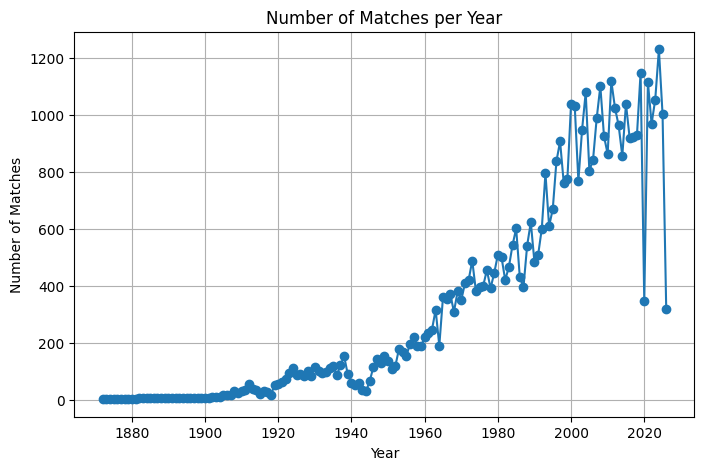

In [6]:
# Group by year and count matches
results["date"] = pd.to_datetime(results["date"])
result = results.groupby(results["date"].dt.year).size().reset_index(name="count")

plt.figure(figsize=(8, 5))
plt.plot(result['date'], result['count'], marker='o')
plt.title("Number of Matches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.grid(True)
plt.show()

### 3.2 Most Frequent Tournaments

This analysis shows us which competitions dominate the dataset. It's useful for:
- Deciding whether to use **tournament type** as a feature (different contexts = different team motivations).
- Assigning **sample weights** later — a FIFA World Cup match should matter more than a friendly.

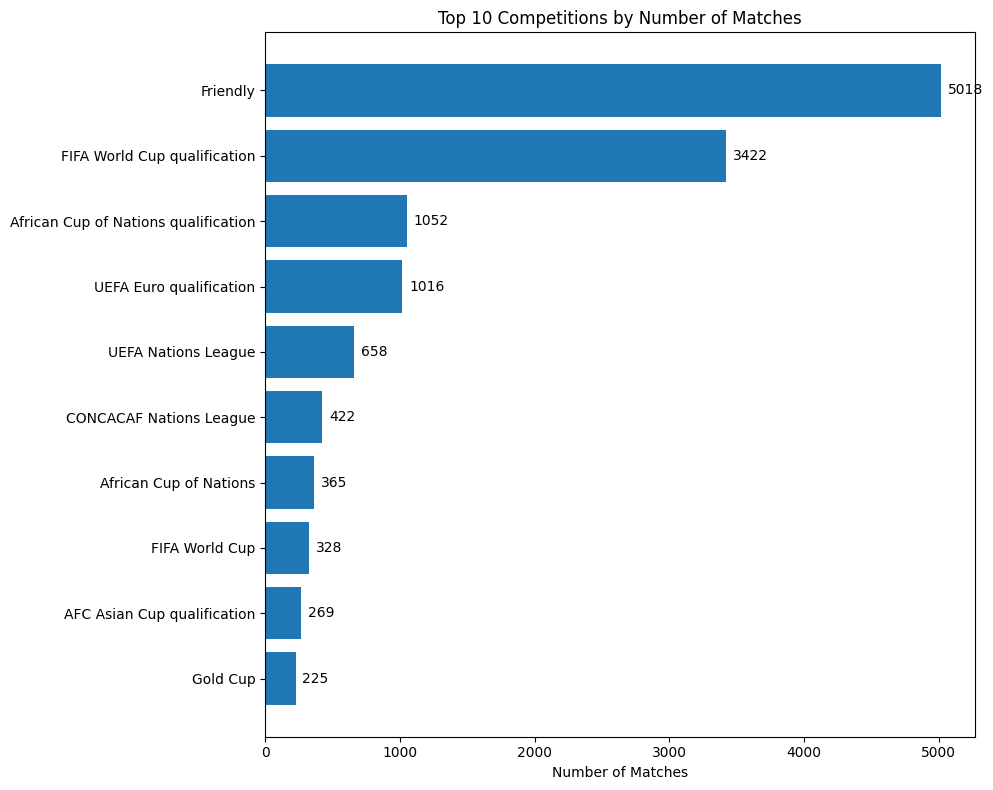

In [7]:
result = results[results["date"] >= pd.Timestamp("2010-01-01")]

result = result.groupby("tournament").agg(
    count=("date", "count"),
    last_date=("date", "max"),
)

top_n = 10
top = result.sort_values("count", ascending=False).head(top_n)

plt.figure(figsize=(10, 8))

# Store bars
bars = plt.barh(top.index.astype(str), top["count"])

# Add values on bars
plt.bar_label(
    bars,
    labels=top["count"],   # optional
    padding=5
)

plt.gca().invert_yaxis()

plt.xlabel("Number of Matches")
plt.title(f"Top {top_n} Competitions by Number of Matches")

plt.tight_layout()
plt.show()

---
## 4. Feature Engineering <a id='features'></a>

### 4.1 Loading & Merging Elo / FIFA Rankings

We combine **FIFA rankings** (from CSV files) and **Elo ratings** (from eloratings.net) into a single unified ranking table.  
For each match, we then look up the most recent ranking available *before* that match date using `pd.merge_asof` (backward join on date).  
This ensures no data leakage — we only use information that would have been available at the time.

In [8]:
rankings_files = [
    'data/fifa_ranking-2023-07-20.csv',
    'data/fifa_ranking-2024-04-04.csv',
    'data/fifa_ranking-2024-06-20.csv'
]

rankings_list = []
for f in rankings_files:
    df = pd.read_csv(f)
    rankings_list.append(df)

# Load Elo ratings from eloratings.net
urls = [
    "https://eloratings.net/2024.tsv",
    "https://eloratings.net/2025.tsv",
    "https://eloratings.net/World.tsv",
]

dfs = []
for url in urls:
    df = pd.read_csv(url, sep=r"\s+", header=None, engine="python")
    if "World.tsv" in url:
        df["rank_date"] = "2026-06-07"
    else:
        year = url.split("/")[-1].replace(".tsv", "")
        df["rank_date"] = f"{year}-12-31"
    dfs.append(df)

elo_df = pd.concat(dfs, ignore_index=True)
elo_df = elo_df[[1, 2, 3, "rank_date"]].rename(columns={1: "rank", 2: "country_full", 3: "total_points"})

rankings = pd.concat(rankings_list, ignore_index=True)
rankings = rankings[['rank_date', 'rank', 'country_full', 'total_points']]

# Combine FIFA and Elo data
rankings = pd.concat([rankings, elo_df], ignore_index=True)
rankings['country_full'] = rankings['country_full'].replace(DATASET_NAME_MAP)
rankings['country_full'] = rankings['country_full'].replace(ELO_ABBR_MAP)

rankings = rankings.drop_duplicates()
rankings['date'] = pd.to_datetime(rankings['rank_date'])
rankings = rankings.sort_values(['date', 'rank']).reset_index(drop=True)

### 4.2 Coverage Check

Before merging, we verify how many teams from the match results dataset are also present in the rankings data. Teams without ranking data will have missing values after the join.

In [9]:
results_teams = set(results['home_team'].unique()) | set(results['away_team'].unique())
ranking_teams = set(rankings['country_full'].unique())
print(f"Teams in results: {len(results_teams)}")
print(f"Teams in rankings: {len(ranking_teams)}")
print(f"Overlap: {len(results_teams & ranking_teams)}")

Teams in results: 334
Teams in rankings: 248
Overlap: 239


### 4.3 Merging Rankings to Match Data

We use a custom function `get_last_elo_asof` that:
1. First tries a **backward** `merge_asof` — find the most recent rating *before or on* the match date.
2. If that still leaves NaNs (e.g., team's first ever match), falls back to a **nearest** merge.

This gives us `home_elo`, `home_rank`, `away_elo`, `away_rank` for each match.

In [10]:
def get_last_elo_asof(results, eloratings, team_col, rating_col_name, rank_col_name):
    """
    For each match, find the most recent Elo rating available before that date.
    Uses backward merge_asof, with a nearest fallback for teams with no prior data.
    """
    team_elo = (
        eloratings[["date", "country_full", "rank", "total_points"]]
        .sort_values("date")
    )

    team_matches = (
        results[["date", team_col]]
        .sort_values("date")
        .drop_duplicates()
        .reset_index(drop=True)
    )

    # Pass 1: backward merge
    merged = pd.merge_asof(
        team_matches, team_elo,
        on="date", left_by=team_col, right_by="country_full",
        direction="backward"
    ).reset_index(drop=True)

    # Pass 2: nearest rescue for remaining NaNs
    still_na = merged["total_points"].isna()
    if still_na.any():
        merged_nearest = pd.merge_asof(
            team_matches[still_na].reset_index(drop=True), team_elo,
            on="date", left_by=team_col, right_by="country_full",
            direction="nearest"
        ).reset_index(drop=True)
        merged.loc[still_na.values, "total_points"] = merged_nearest["total_points"].values
        merged.loc[still_na.values, "rank"] = merged_nearest["rank"].values

    return (
        merged[["date", team_col, "total_points", "rank"]]
        .rename(columns={"total_points": rating_col_name, "rank": rank_col_name})
    )

In [11]:
results = results.merge(
    get_last_elo_asof(results, rankings, "home_team", "home_elo", "home_rank"),
    on=["date", "home_team"], how="left"
)

results = results.merge(
    get_last_elo_asof(results, rankings, "away_team", "away_elo", "away_rank"),
    on=["date", "away_team"], how="left"
)

In [12]:
# Check remaining missing values after merge
results.isna().sum()

date             0
home_team        0
away_team        0
home_score      72
away_score      72
tournament       0
city             0
country          0
neutral          0
home_elo      1079
home_rank     1082
away_elo      1212
away_rank     1218
dtype: int64

### 4.4 Filtering to Modern Era (2000+)

Based on the EDA above, we restrict the dataset to matches from **2000 onwards**. This gives us ~25k matches — a good balance between sufficient data and relevance to the modern game. Remaining NaN rows (teams with no ranking data at all) are dropped.

In [13]:
print(results[results['date'] >= '2000-01-01'].shape)
print(results[results['date'] >= '2000-01-01'].isna().sum())

(25349, 13)
date            0
home_team       0
away_team       0
home_score     72
away_score     72
tournament      0
city            0
country         0
neutral         0
home_elo      628
home_rank     631
away_elo      567
away_rank     573
dtype: int64


In [14]:
results = results[results['date'] >= pd.Timestamp('2000-01-01')].copy()

### 4.5 Rolling Form Features

Static ratings (Elo/FIFA rank) capture overall team strength but miss **recent form**.  
We compute rolling window features over the last **3**, **5** and **10** matches for each team:

| Feature | Meaning |
|---------|--------|
| `avg_scored_N` | Average goals scored in last N matches |
| `avg_conceded_N` | Average goals conceded in last N matches |
| `win_rate_N` | Win percentage in last N matches |

**Important**: We use `shift(1)` to avoid data leakage — the current match is never included in its own rolling window.

In [15]:
def compute_team_rolling_features(results, n):
    """
    Compute rolling avg goals scored, conceded, and win rate
    for both home and away team — fully vectorized, no loops.
    """
    results = results.sort_values("date").reset_index(drop=True)

    # Build a unified long-format table: one row per team per match
    home = results[["date", "home_team", "away_team", "home_score", "away_score"]].copy()
    home.columns = ["date", "team", "opponent", "goals_scored", "goals_conceded"]
    home["win"] = (home["goals_scored"] > home["goals_conceded"]).astype(int)

    away = results[["date", "away_team", "home_team", "away_score", "home_score"]].copy()
    away.columns = ["date", "team", "opponent", "goals_scored", "goals_conceded"]
    away["win"] = (away["goals_scored"] > away["goals_conceded"]).astype(int)

    long = pd.concat([home, away]).sort_values(["team", "date"]).reset_index(drop=True)

    # Rolling features per team — shift(1) avoids leakage
    long[f"avg_scored_{n}"] = long.groupby("team")["goals_scored"].transform(
        lambda x: x.shift(1).rolling(n, min_periods=1).mean()
    )
    long[f"avg_conceded_{n}"] = long.groupby("team")["goals_conceded"].transform(
        lambda x: x.shift(1).rolling(n, min_periods=1).mean()
    )
    long[f"win_rate_{n}"] = long.groupby("team")["win"].transform(
        lambda x: x.shift(1).rolling(n, min_periods=1).mean()
    )

    # Split back to home and away
    home_feats = long[long["team"].isin(results["home_team"])].copy()
    home_feats = home_feats.rename(columns={
        f"avg_scored_{n}": f"home_avg_scored_{n}",
        f"avg_conceded_{n}": f"home_avg_conceded_{n}",
        f"win_rate_{n}": f"home_win_rate_{n}",
    })

    away_feats = long[long["team"].isin(results["away_team"])].copy()
    away_feats = away_feats.rename(columns={
        f"avg_scored_{n}": f"away_avg_scored_{n}",
        f"avg_conceded_{n}": f"away_avg_conceded_{n}",
        f"win_rate_{n}": f"away_win_rate_{n}",
    })

    # Join back to original results
    results = results.merge(
        home_feats[["date", "team", f"home_avg_scored_{n}", f"home_avg_conceded_{n}", f"home_win_rate_{n}"]],
        left_on=["date", "home_team"], right_on=["date", "team"], how="left"
    ).drop(columns="team")

    results = results.merge(
        away_feats[["date", "team", f"away_avg_scored_{n}", f"away_avg_conceded_{n}", f"away_win_rate_{n}"]],
        left_on=["date", "away_team"], right_on=["date", "team"], how="left"
    ).drop(columns="team")

    return results

In [16]:
# Compute rolling features for windows of 3, 5 and 10 matches
for n in [3, 5, 10]:
    results = compute_team_rolling_features(results, n)

In [17]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,home_win_rate_5,away_avg_scored_5,away_avg_conceded_5,away_win_rate_5,home_avg_scored_10,home_avg_conceded_10,home_win_rate_10,away_avg_scored_10,away_avg_conceded_10,away_win_rate_10
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False,556.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False,596.0,...,NaN,1.000000,2.000000,0.0,NaN,NaN,NaN,1.000,2.000,0.0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,536.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False,456.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True,453.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156400,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,1680.0,...,0.0,3.000000,0.333333,0.6,1.875,1.500,0.4,2.500,0.375,0.6
156401,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,1982.0,...,0.2,3.666667,0.333333,0.4,2.500,1.250,0.5,2.750,0.875,0.5
156402,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,Kansas City,United States,True,1772.0,...,0.4,2.333333,0.333333,0.6,2.000,0.375,0.6,2.750,0.500,0.6
156403,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,1730.0,...,0.4,1.000000,0.666667,0.2,2.000,1.750,0.4,2.500,0.250,0.6


---
## 5. Model Training & Evaluation <a id='models'></a>

### 5.1 Encoding & Derived Features

We encode `tournament` with `LabelEncoder`, compute **elo_diff** / **rank_diff** features, and use **target encoding** for team identity (mean goals scored per team, computed from training data only to avoid leakage).

In [18]:
le_tournament = LabelEncoder()
results["tournament_encoded"] = le_tournament.fit_transform(results["tournament"])

# --- Difference features (captures the gap directly) ---
results["elo_diff"] = results["home_elo"] - results["away_elo"]
results["rank_diff"] = results["away_rank"] - results["home_rank"]  # positive = home team ranked higher

### 5.2 Feature Selection & Target Definition

We select features capturing:
- **Venue context**: `neutral`
- **Static strength**: `home_elo`, `home_rank`, `away_elo`, `away_rank`
- **Strength gap**: `elo_diff`, `rank_diff` — models the relative difference directly
- **Recent form** (3, 5 & 10 match windows): goals scored/conceded averages, win rates
- **Match context**: `tournament_encoded`
- **Team identity** (target encoded): `home_team_enc`, `away_team_enc` — average goals scored by each team, computed only from training data

**Target**: `home_score` and `away_score` (multi-output regression).

In [19]:
# keep WC 2026 matches with missing scores for final prediction
wc_2026 = results[results['home_score'].isna()]

results.dropna(inplace = True)

In [20]:
FEATURES = [
    'neutral', 'home_elo', 'home_rank', 'away_elo', 'away_rank',
    'elo_diff', 'rank_diff',
    'home_avg_scored_3', 'home_avg_conceded_3', 'home_win_rate_3',
    'away_avg_scored_3', 'away_avg_conceded_3', 'away_win_rate_3',
    'home_avg_scored_5', 'home_avg_conceded_5', 'home_win_rate_5',
    'away_avg_scored_5', 'away_avg_conceded_5', 'away_win_rate_5',
    'home_avg_scored_10', 'home_avg_conceded_10', 'home_win_rate_10',
    'away_avg_scored_10', 'away_avg_conceded_10', 'away_win_rate_10',
    'tournament_encoded', 'home_team_enc', 'away_team_enc'
]

# --- Temporal split first (to avoid target encoding leakage) ---
split_idx = int(len(results) * 0.8)
train_df = results.iloc[:split_idx]
test_df = results.iloc[split_idx:]

# --- Target encoding for teams (computed from train set only) ---
# Home team: mean of home_score when playing at home
home_enc_map = train_df.groupby('home_team')['home_score'].mean()
# Away team: mean of away_score when playing away
away_enc_map = train_df.groupby('away_team')['away_score'].mean()

global_home_mean = train_df['home_score'].mean()
global_away_mean = train_df['away_score'].mean()

results['home_team_enc'] = results['home_team'].map(home_enc_map).fillna(global_home_mean)
results['away_team_enc'] = results['away_team'].map(away_enc_map).fillna(global_away_mean)

X = results[FEATURES].values
y_home = results["home_score"].values
y_away = results["away_score"].values
y = np.column_stack([y_home, y_away])

print(f"Final dataset size: {results.shape[0]} matches, {len(FEATURES)} features")

Final dataset size: 155371 matches, 28 features


### 5.3 Sample Weights by Tournament Importance

Not all matches are equal — a World Cup final carries far more signal than a random friendly.  
We assign **sample weights** so the model pays more attention to competitive matches during training.

In [21]:
TOURNAMENTS_WEIGHTS = {
    'FIFA World Cup': 5.0,
    'UEFA Euro': 4.2,
    'Copa América': 4.0,
    'African Cup of Nations': 3.6,

    'FIFA World Cup qualification': 2.8,
    'UEFA Euro qualification': 2.5,
    'UEFA Nations League': 2.0,
    'Friendly': 0.5
}

DEFAULT_WEIGHT = 1.2

sample_weights = results['tournament'].map(TOURNAMENTS_WEIGHTS).fillna(DEFAULT_WEIGHT).values

### 5.4 Temporal Train/Test Split

We use a **chronological split** (85% train / 15% test) rather than random splitting.  
This is crucial for time-series problems — we must never train on future data to predict the past.

In [22]:
split_idx = int(len(X) * 0.85)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
y_home_train, y_home_test = y_home[:split_idx], y_home[split_idx:]
y_away_train, y_away_test = y_away[:split_idx], y_away[split_idx:]
w_train = sample_weights[:split_idx]

print(f"Train size = {len(X_train)}, Test size = {len(X_test)}")

Train size = 132065, Test size = 23306


### 5.5 Evaluation Function

We evaluate models on:
- **MAE / MSE** for home and away goals (regression quality)
- **Outcome Accuracy** (Win/Draw/Loss) — the most practically useful metric
- **Exact Score Accuracy** — predictions are **rounded to integers** before comparison

In [ ]:
def evaluate(name, y_true_home, y_pred_home, y_true_away, y_pred_away): 
    """Compute metrics for a model.""" 
    mae_home = mean_absolute_error(y_true_home, y_pred_home) 
    mae_away = mean_absolute_error(y_true_away, y_pred_away) 
    mse_home = mean_squared_error(y_true_home, y_pred_home) 
    mse_away = mean_squared_error(y_true_away, y_pred_away) 
    
    # Outcome accuracy (W/D/L) 
    true_outcome = np.sign(y_true_home - y_true_away) 
    pred_outcome = np.sign(y_pred_home - y_pred_away) 
    outcome_acc = (true_outcome == pred_outcome).mean() 

    # # Exact score accuracy (round predictions to integers) 
    pred_h_rounded = np.floor(y_pred_home).astype(int) 
    pred_a_rounded = np.floor(y_pred_away).astype(int)
 
    exact_acc = ((y_true_home == pred_h_rounded) & (y_true_away == pred_a_rounded)).mean() 
 
    print(f"{'='*50}") 
    print(f"{name} Results:") 
    print(f"{'='*50}") 
    print(f" Home Goals - MAE: {mae_home:.3f}, MSE: {mse_home:.3f}") 
    print(f" Away Goals - MAE: {mae_away:.3f}, MSE: {mse_away:.3f}") 
    print(f" Avg MAE: {(mae_home + mae_away)/2:.3f}") 
    print(f" Outcome Accuracy (W/D/L): {outcome_acc:.3%}") 
    print(f" Exact Score Accuracy: {exact_acc:.3%}") 

    return {'model': name, 
            'mae_home': mae_home, 
            'mae_away': mae_away, 
            'mse_home': mse_home, 
            'mse_away': mse_away, 
            'avg_mae': (mae_home + mae_away)/2, 
            'outcome_acc': outcome_acc, 
            'exact_acc': exact_acc }

### 5.6 Training Multiple Models

We train and compare three different approaches:

1. **Poisson Regression** — theoretically appropriate since goals are count data following a Poisson-like distribution.
2. **Random Forest** — ensemble of decision trees, robust to outliers.
3. **XGBoost** — gradient boosting, usually best for tabular data.

Predictions are rounded to integers for exact score evaluation.

In [24]:
model_results = list()

# -- Random Forest -- #
print("\nTraining Random Forest...")
rf_home = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_away = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_home.fit(X_train, y_home_train, sample_weight=w_train)
rf_away.fit(X_train, y_away_train, sample_weight=w_train)
pred_h = rf_home.predict(X_test)
pred_a = rf_away.predict(X_test)
model_results.append(evaluate("Random Forest", y_home_test, pred_h, y_away_test, pred_a))

# -- XGBoost -- #
print("\nTraining XGBoost...")
xgb_home = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0)
xgb_away = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0)
xgb_home.fit(X_train, y_home_train, sample_weight=w_train)
xgb_away.fit(X_train, y_away_train, sample_weight=w_train)
pred_h = xgb_home.predict(X_test)
pred_a = xgb_away.predict(X_test)
model_results.append(evaluate("XGBoost", y_home_test, pred_h, y_away_test, pred_a))


Training Random Forest...
Random Forest Results:
 Home Goals - MAE: 1.581, MSE: 4.122
 Away Goals - MAE: 1.023, MSE: 1.553
 Avg MAE: 1.302
 Outcome Accuracy (W/D/L): 63.185%
 Exact Score Accuracy: 0.532%

Training XGBoost...
XGBoost Results:
 Home Goals - MAE: 1.564, MSE: 3.450
 Away Goals - MAE: 1.115, MSE: 1.862
 Avg MAE: 1.339
 Outcome Accuracy (W/D/L): 56.415%
 Exact Score Accuracy: 1.266%


In [27]:
# --- Define param grid ---
param_grid = {
    "estimator__n_estimators":  [200, 300, 500],
    "estimator__max_depth":     [3, 5, 6, 8],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__subsample":     [0.7, 0.8, 1.0],
    "estimator__colsample_bytree": [0.7, 0.8, 1.0],
    "estimator__min_child_weight": [1, 3, 5],
}

# --- Wrap in MultiOutput so home + away are tuned together ---
multi_xgb = MultiOutputRegressor(
    XGBRegressor(random_state=42, verbosity=0)
)

random_search = RandomizedSearchCV(
    estimator=multi_xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True
)

y_train_combined = np.column_stack([y_home_train, y_away_train])

random_search.fit(X_train, y_train_combined, sample_weight=w_train)

print("Best params:", random_search.best_params_)
print("Best MAE:   ", -random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'estimator__subsample': 0.8, 'estimator__n_estimators': 200, 'estimator__min_child_weight': 3, 'estimator__max_depth': 6, 'estimator__learning_rate': 0.1, 'estimator__colsample_bytree': 0.7}
Best MAE:    0.5552774025151783


### 5.7 Train Best model and Predict WC 2026

We retrain now the best model **XGBoost** with params got from RandomizedSearch method and then predict the group stage WC 2026 result


In [28]:
# --- Temporal split first (to avoid target encoding leakage) ---
train_df = results

# --- Target encoding for teams (computed from train set only) ---
# Home team: mean of home_score when playing at home
home_enc_map = train_df.groupby('home_team')['home_score'].mean()
# Away team: mean of away_score when playing away
away_enc_map = train_df.groupby('away_team')['away_score'].mean()

global_home_mean = train_df['home_score'].mean()
global_away_mean = train_df['away_score'].mean()

results['home_team_enc'] = results['home_team'].map(home_enc_map).fillna(global_home_mean)
results['away_team_enc'] = results['away_team'].map(away_enc_map).fillna(global_away_mean)

X = results[FEATURES].values
y_home = results["home_score"].values
y_away = results["away_score"].values
y = np.column_stack([y_home, y_away])

print(f"Final dataset size: {results.shape[0]} matches, {len(FEATURES)} features")

Final dataset size: 155371 matches, 28 features


In [29]:
# --- Phase 2: retrain on full dataset ---
xgb_home_final = XGBRegressor(**random_search.best_params_, random_state=42, verbosity=0)
xgb_away_final = XGBRegressor(**random_search.best_params_, random_state=42, verbosity=0)


xgb_home_final.fit(X, y_home, sample_weight=sample_weights)
xgb_away_final.fit(X, y_away, sample_weight=sample_weights)

print("Final model trained on full history ✓")

Final model trained on full history ✓


In [30]:
# using data UP TO June 11 2026 — no leakage
wc_2026['home_team_enc'] = wc_2026['home_team'].map(home_enc_map).fillna(global_home_mean)
wc_2026['away_team_enc'] = wc_2026['away_team'].map(away_enc_map).fillna(global_away_mean)

X_wc = wc_2026[FEATURES]

wc_2026["pred_home"] = np.floor(xgb_home_final.predict(X_wc).clip(0)).astype(int)
wc_2026["pred_away"] = np.floor(xgb_away_final.predict(X_wc).clip(0)).astype(int)

wc_2026[["home_team", "away_team", "pred_home", "pred_away"]]

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1908\1917097163.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wc_2026['home_team_enc'] = wc_2026['home_team'].map(home_enc_map).fillna(global_home_mean)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1908\1917097163.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wc_2026['away_team_enc'] = wc_2026['away_team'].map(away_enc_map).fillna(global_away_mean)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1908\1917097163.py:7: SettingWithCopyWarning: 
A value is tryi

,home_team,away_team,pred_home,pred_away
156333,South Korea,Czech Republic,1,0
156334,Mexico,South Africa,2,0
156335,Canada,Bosnia and Herzegovina,1,1
156336,USA,Paraguay,1,1
156337,Australia,Turkey,1,1
...,...,...,...,...
156400,Jordan,Argentina,0,2
156401,Colombia,Portugal,0,1
156402,Algeria,Austria,1,1
156403,Panama,England,1,3


This section of the notebook computes and displays the final standings for each group of the World Cup 2026 group stage simulation.

## 6. Group Standings Computation <a id='standings'></a>

For each group, teams are ranked based on their performance across all group matches. The following metrics are computed for every team:

- **Played (MP)**: Total number of matches played  
- **Wins (W)**: Number of matches won  
- **Draws (D)**: Number of matches drawn  
- **Losses (L)**: Number of matches lost  
- **Goals For (GF)**: Total goals scored by the team  
- **Goals Against (GA)**: Total goals conceded  
- **Goal Difference (GD)**: GF - GA  
- **Points (Pts)**: 3 points for a win, 1 point for a draw, 0 for a loss  

The result is a ranked table for each group showing the final standings.

---

#### Best 3rd-Placed Teams Ranking

After computing all group standings, the third-placed team from each group is extracted.

The top-ranked third-placed teams are selected to complete the Round of 32 bracket.

---

#### Output of This Section

This code produces:
- A final ranked table for each group
- A consolidated ranking of all third-placed teams
- A list of qualified teams for the knockout stage

In [31]:
wc2026_groups = {
    'A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Norway', 'Iraq'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

In [32]:
# Your predictions df (already loaded)
# df columns: home_team, away_team, pred_home, pred_away

def compute_group_standings(df, groups):
    """
    df: match predictions with pred_home, pred_away
    groups: dict {'A': ['Mexico', 'South Africa', ...], ...}
    """
    records = []

    for group, teams in groups.items():
        # Filter matches for this group
        mask = (
            df['home_team'].isin(teams) & df['away_team'].isin(teams)
        )
        group_matches = df[mask].copy()

        # Init stats per team
        stats = {t: {'Group': group, 'Team': t, 'MP': 0, 'W': 0, 'D': 0,
                     'L': 0, 'GF': 0, 'GA': 0, 'GD': 0, 'Pts': 0}
                 for t in teams}

        for _, row in group_matches.iterrows():
            h, a = row['home_team'], row['away_team']
            gh, ga = int(row['pred_home']), int(row['pred_away'])

            # Goals
            stats[h]['GF'] += gh; stats[h]['GA'] += ga
            stats[a]['GF'] += ga; stats[a]['GA'] += gh
            stats[h]['MP'] += 1;  stats[a]['MP'] += 1

            # Result
            if gh > ga:      # Home win
                stats[h]['W'] += 1; stats[h]['Pts'] += 3
                stats[a]['L'] += 1
            elif gh < ga:    # Away win
                stats[a]['W'] += 1; stats[a]['Pts'] += 3
                stats[h]['L'] += 1
            else:            # Draw
                stats[h]['D'] += 1; stats[h]['Pts'] += 1
                stats[a]['D'] += 1; stats[a]['Pts'] += 1

        for t in teams:
            stats[t]['GD'] = stats[t]['GF'] - stats[t]['GA']
            records.append(stats[t])

    standings = pd.DataFrame(records)
    return standings


# Build standings
standings = compute_group_standings(wc_2026[["home_team", "away_team", "pred_home", "pred_away"]], wc2026_groups)

In [33]:
def rank_group(standings):
    return (
        standings
        .sort_values(['Group', 'Pts', 'GD', 'GF'], ascending=[True, False, False, False])
        .assign(Rank=lambda x: x.groupby('Group').cumcount() + 1)
    )

standings = rank_group(standings)

In [34]:
def display_all_groups(standings):
    cols = ['Rank', 'Team', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']
    for group in sorted(standings['Group'].unique()):
        g = standings[standings['Group'] == group][cols]
        print(f"\n{'='*45}")
        print(f"  GROUP {group}")
        print(f"{'='*45}")
        print(g.to_string(index=False))

display_all_groups(standings)


  GROUP A
 Rank           Team  MP  W  D  L  GF  GA  GD  Pts
    1         Mexico   3  2  1  0   4   1   3    7
    2    South Korea   3  2  1  0   3   1   2    7
    3 Czech Republic   3  1  0  2   2   2   0    3
    4   South Africa   3  0  0  3   0   5  -5    0

  GROUP B
 Rank                   Team  MP  W  D  L  GF  GA  GD  Pts
    1            Switzerland   3  2  1  0   2   0   2    7
    2                 Canada   3  1  2  0   3   1   2    5
    3 Bosnia and Herzegovina   3  1  1  1   2   2   0    4
    4                  Qatar   3  0  0  3   0   4  -4    0

  GROUP C
 Rank     Team  MP  W  D  L  GF  GA  GD  Pts
    1   Brazil   3  3  0  0   6   2   4    9
    2  Morocco   3  1  1  1   3   4  -1    4
    3 Scotland   3  0  2  1   2   3  -1    2
    4    Haiti   3  0  1  2   2   4  -2    1

  GROUP D
 Rank          Team  MP  W  D  L  GF  GA  GD  Pts
    1      Paraguay   2  0  2  0   2   2   0    2
    2     Australia   2  0  2  0   2   2   0    2
    3        Turkey   2  0  2  

In [35]:
# Top 2 from each group → 24 teams
top2 = standings[standings['Rank'] <= 2].copy()

# All 3rd-placed teams (12 groups × 1 = 12 teams)
third_place = standings[standings['Rank'] == 3].copy()

# Best 8 third-placed (sorted by Pts → GD → GF)
best_third = (
    third_place
    .sort_values(['Pts', 'GD', 'GF'], ascending=False)
    .head(8)
    .reset_index(drop=True)
    .assign(Rank_3rd=lambda x: x.index + 1)
)

print("\n=== BEST 8 THIRD-PLACE TEAMS ===")
print(best_third[['Rank_3rd', 'Group', 'Team', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']])

# Round of 32 qualifiers = top2 (24) + best_third (8) = 32 teams
r32 = pd.concat([top2, best_third[top2.columns]], ignore_index=True)
print(f"\nRound of 32: {len(r32)} teams qualified")


=== BEST 8 THIRD-PLACE TEAMS ===
   Rank_3rd Group                    Team  MP  W  D  L  GF  GA  GD  Pts
0         1     E             Ivory Coast   3  1  1  1   3   1   2    4
1         2     L                 Croatia   3  1  1  1   3   3   0    4
2         3     B  Bosnia and Herzegovina   3  1  1  1   2   2   0    4
3         4     H            Saudi Arabia   3  1  1  1   2   2   0    4
4         5     J                 Austria   3  1  1  1   2   2   0    4
5         6     I                 Senegal   3  1  0  2   3   3   0    3
6         7     A          Czech Republic   3  1  0  2   2   2   0    3
7         8     F                  Sweden   3  1  0  2   2   4  -2    3

Round of 32: 32 teams qualified
